In [73]:
import os
import re

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

### 1. Missing Value Profiling and Handling Strategy

In [74]:
df = pd.read_csv(filepath_or_buffer="netflix_titles.csv")

In [75]:
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [76]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   show_id       8807 non-null   str  
 1   type          8807 non-null   str  
 2   title         8807 non-null   str  
 3   director      6173 non-null   str  
 4   cast          7982 non-null   str  
 5   country       7976 non-null   str  
 6   date_added    8797 non-null   str  
 7   release_year  8807 non-null   int64
 8   rating        8803 non-null   str  
 9   duration      8804 non-null   str  
 10  listed_in     8807 non-null   str  
 11  description   8807 non-null   str  
dtypes: int64(1), str(11)
memory usage: 3.9 MB


In [77]:
df.isnull().sum()

show_id            0
type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_year       0
rating             4
duration           3
listed_in          0
description        0
dtype: int64

I do not think there is a need to drop those rows where there are some `NaN` values. Better is to fill them with boilerplate `unrecorder` value - we already are short of data, dropping them will cause distorted analysis.

In [78]:
df = df.fillna(value="unrecorder")

In [79]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   show_id       8807 non-null   str  
 1   type          8807 non-null   str  
 2   title         8807 non-null   str  
 3   director      8807 non-null   str  
 4   cast          8807 non-null   str  
 5   country       8807 non-null   str  
 6   date_added    8807 non-null   str  
 7   release_year  8807 non-null   int64
 8   rating        8807 non-null   str  
 9   duration      8807 non-null   str  
 10  listed_in     8807 non-null   str  
 11  description   8807 non-null   str  
dtypes: int64(1), str(11)
memory usage: 3.9 MB


### 2. Duration Parsing and Standardization

In [80]:
df["type"].unique()

<ArrowStringArray>
['Movie', 'TV Show']
Length: 2, dtype: str

In [81]:
df["duration_minutes"] = (
    df["duration"]
    .where(df["duration"].str.contains("min", na=False))
    .str.split()
    .str[0]
    .astype("float")
)

df["duration_seasons"] = (
    df["duration"]
    .where(df["duration"].str.lower().str.contains("season", na=False))
    .str.split()
    .str[0]
    .astype("float")
)

In [82]:
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,duration_minutes,duration_seasons
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,unrecorder,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm...",90.0,NaN
1,s2,TV Show,Blood & Water,unrecorder,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t...",NaN,2.0
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",unrecorder,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...,NaN,1.0
3,s4,TV Show,Jailbirds New Orleans,unrecorder,unrecorder,unrecorder,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo...",NaN,1.0
4,s5,TV Show,Kota Factory,unrecorder,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...,NaN,2.0


### 3. Temporal Format Standardization

In [83]:
df["date_added"] = pd.to_datetime(
    df["date_added"].str.strip(),
    format="%B %d, %Y",
    errors="coerce",
)

In [84]:
df["date_added"].head()

0   2021-09-25
1   2021-09-24
2   2021-09-24
3   2021-09-24
4   2021-09-24
Name: date_added, dtype: datetime64[us]

In [85]:
(df["date_added"].dtype)

dtype('<M8[us]')

In [86]:
df["date_added"].isnull().sum()

np.int64(10)

In [87]:
df["date_added_year"] = df["date_added"].dt.year
df["date_added_month"] = df["date_added"].dt.month
df["date_added_day"] = df["date_added"].dt.day

In [88]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 17 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   show_id           8807 non-null   str           
 1   type              8807 non-null   str           
 2   title             8807 non-null   str           
 3   director          8807 non-null   str           
 4   cast              8807 non-null   str           
 5   country           8807 non-null   str           
 6   date_added        8797 non-null   datetime64[us]
 7   release_year      8807 non-null   int64         
 8   rating            8807 non-null   str           
 9   duration          8807 non-null   str           
 10  listed_in         8807 non-null   str           
 11  description       8807 non-null   str           
 12  duration_minutes  6128 non-null   float64       
 13  duration_seasons  2676 non-null   float64       
 14  date_added_year   8797 non-null   f

### 4. Format Strategy Over Time

### 4. Format Strategy Over Time
Task: Calculate the proportion of the catalog that consists of Movies versus TV Shows. Trace how this proportion has shifted based on the release_year over the past 20 years to determine if the primary format focus is shifting.
Skill: Descriptive Analytics and Trend Visualization
Why: Establishing the fundamental business division and observing its longitudinal trajectory provides essential context for evaluating company strategy.

In [89]:
year_type_titles = (
    df.groupby(by=["release_year", "type"])
    .agg(titles=("show_id", "count"))
    .sort_values(by="release_year")
    .reset_index()
)

In [90]:
year_type_titles.head()

,release_year,type,titles
0,1925,TV Show,1
1,1942,Movie,2
2,1943,Movie,3
3,1944,Movie,3
4,1945,Movie,3


In [91]:
pivot_data = (
    year_type_titles.pivot(
        index="release_year",
        columns="type",
        values="titles",
    )
    .fillna(0)
    .sort_index()
)


In [92]:
pivot_data.head()

type,Movie,TV Show
release_year,,
1925,0.0,1.0
1942,2.0,0.0
1943,3.0,0.0
1944,3.0,0.0
1945,3.0,1.0


In [93]:
# if "Movie" not in pivot_data.columns:
# checks if the column named "Movie" exists in the pivoted DataFrame.
# pivot_data["Movie"] = 0 initializes a new column named "Movie"
# populated entirely with zeros if it was missing.
# The same logic is applied to "TV Show".

if "Movie" not in pivot_data.columns:
    pivot_data["Movie"] = 0
if "TV Show" not in pivot_data.columns:
    pivot_data["TV Show"] = 0

In [94]:
pivot_data["Total"] = pivot_data["Movie"] + pivot_data["TV Show"]
pivot_data["Movie_Pct"] = (
    pivot_data["Movie"] / pivot_data["Total"].replace(0, 1)
) * 100
pivot_data["TV_Pct"] = (
    pivot_data["TV Show"] / pivot_data["Total"].replace(0, 1)
) * 100

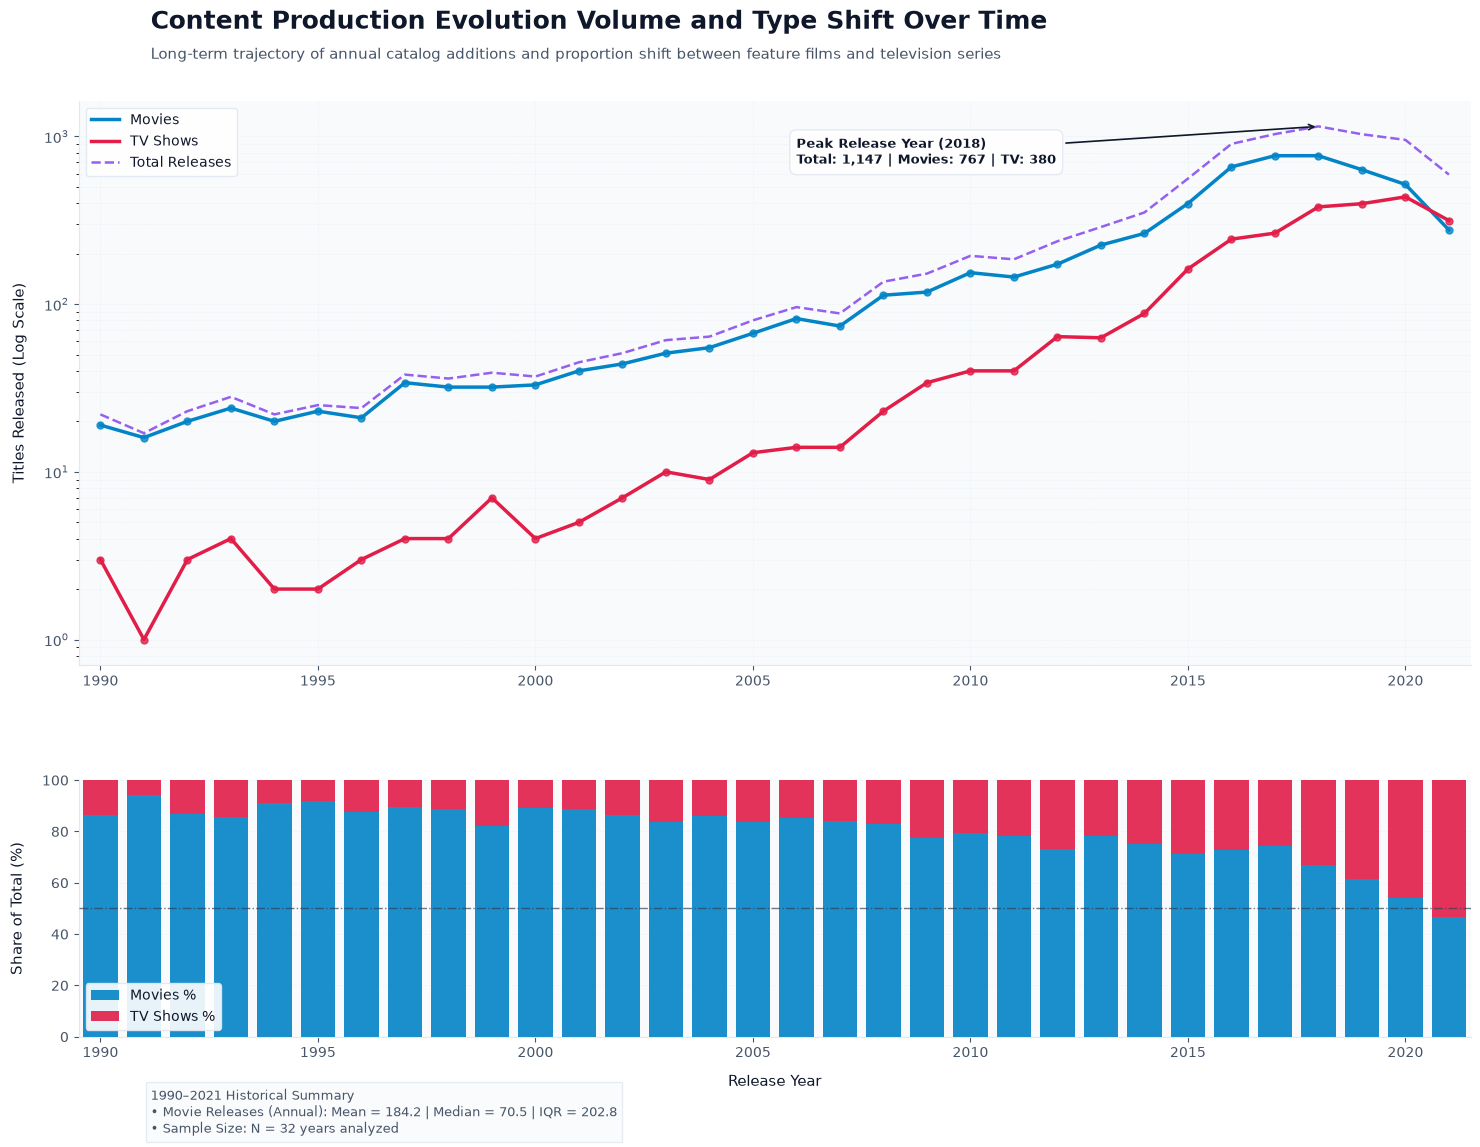

In [96]:
all_years = np.arange(pivot_data.index.min(), pivot_data.index.max() + 1)
pivot_data = pivot_data.reindex(all_years, fill_value=0)

recent_data = pivot_data.loc[pivot_data.index >= 1990]

BG_COLOR = "#FFFFFF"
PANEL_BG = "#F8FAFC"
TEXT_COLOR = "#0F172A"
MUTED_TEXT = "#475569"
MOVIE_COLOR = "#0284C7"
TV_COLOR = "#E11D48"
GRID_COLOR = "#E2E8F0"

title_text = "Content Production Evolution Volume and Type Shift Over Time"

fig = plt.figure(figsize=(16, 12), facecolor=BG_COLOR)
gs = fig.add_gridspec(2, 1, height_ratios=[2.2, 1], hspace=0.28)

ax0 = fig.add_subplot(gs[0], facecolor=PANEL_BG)
ax1 = fig.add_subplot(gs[1], facecolor=PANEL_BG)

years = recent_data.index.values
movies = recent_data["Movie"].values
tv_shows = recent_data["TV Show"].values
totals = recent_data["Total"].values

ax0.plot(
    years, movies, color=MOVIE_COLOR, linewidth=2.5, label="Movies", zorder=4
)
ax0.scatter(years, movies, color=MOVIE_COLOR, s=25, alpha=0.8, zorder=5)

ax0.plot(
    years, tv_shows, color=TV_COLOR, linewidth=2.5, label="TV Shows", zorder=4
)
ax0.scatter(years, tv_shows, color=TV_COLOR, s=25, alpha=0.8, zorder=5)

ax0.plot(
    years,
    totals,
    color="#7C3AED",
    linewidth=1.8,
    linestyle="--",
    label="Total Releases",
    alpha=0.8,
    zorder=3,
)

ax0.set_yscale("log")
ax0.grid(
    True,
    which="both",
    linestyle=":",
    linewidth=0.5,
    color=GRID_COLOR,
    alpha=0.8,
)
ax0.set_ylabel(
    "Titles Released (Log Scale)", color=TEXT_COLOR, fontsize=11, labelpad=12
)

max_year = recent_data["Total"].idxmax()
max_total = recent_data.loc[max_year, "Total"]
max_movie = recent_data.loc[max_year, "Movie"]
max_tv = recent_data.loc[max_year, "TV Show"]

ax0.annotate(
    f"Peak Release Year ({max_year})\nTotal: {int(max_total):,} | Movies: {int(max_movie):,} | TV: {int(max_tv):,}",
    xy=(max_year, max_total),
    xytext=(max_year - 12, max_total * 0.6),
    arrowprops={"arrowstyle": "->", "color": TEXT_COLOR, "lw": 1.2},
    color=TEXT_COLOR,
    fontsize=9.5,
    fontweight="bold",
    bbox={
        "boxstyle": "round,pad=0.5",
        "facecolor": BG_COLOR,
        "edgecolor": GRID_COLOR,
        "alpha": 0.9,
    },
)

movie_pcts = recent_data["Movie_Pct"].values
tv_pcts = recent_data["TV_Pct"].values

ax1.bar(
    years,
    movie_pcts,
    color=MOVIE_COLOR,
    label="Movies %",
    width=0.8,
    alpha=0.9,
    zorder=3,
)
ax1.bar(
    years,
    tv_pcts,
    bottom=movie_pcts,
    color=TV_COLOR,
    label="TV Shows %",
    width=0.8,
    alpha=0.9,
    zorder=3,
)

ax1.axhline(
    50, color="#334155", linestyle="-.", linewidth=1, alpha=0.7, zorder=4
)
ax1.set_ylabel("Share of Total (%)", color=TEXT_COLOR, fontsize=11, labelpad=12)
ax1.set_ylim(0, 100)
ax1.set_xlabel("Release Year", color=TEXT_COLOR, fontsize=11, labelpad=10)
ax1.grid(
    True,
    which="major",
    linestyle=":",
    linewidth=0.5,
    color=GRID_COLOR,
    alpha=0.8,
)

for ax in [ax0, ax1]:
    ax.tick_params(colors=MUTED_TEXT, labelsize=10)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_color(GRID_COLOR)
    ax.spines["bottom"].set_color(GRID_COLOR)
    ax.set_xlim(years.min() - 0.5, years.max() + 0.5)

ax0.set_xticks(np.arange(1990, years.max() + 1, 5))
ax1.set_xticks(np.arange(1990, years.max() + 1, 5))

mean_movies = recent_data["Movie"].mean()
median_movies = recent_data["Movie"].median()
iqr_movies = recent_data["Movie"].quantile(0.75) - recent_data[
    "Movie"
].quantile(0.25)

stats_str = (
    f"1990–{years.max()} Historical Summary\n"
    f"• Movie Releases (Annual): Mean = {mean_movies:.1f} | Median = {median_movies:.1f} | IQR = {iqr_movies:.1f}\n"
    f"• Sample Size: N = {len(recent_data)} years analyzed"
)

fig.text(
    0.125, 0.94, title_text, color=TEXT_COLOR, fontsize=18, fontweight="bold"
)
fig.text(
    0.125,
    0.915,
    "Long-term trajectory of annual catalog additions and proportion shift between feature films and television series",
    color=MUTED_TEXT,
    fontsize=11,
)

fig.text(
    0.125,
    0.02,
    stats_str,
    color=MUTED_TEXT,
    fontsize=9,
    bbox={
        "boxstyle": "square,pad=0.4",
        "facecolor": PANEL_BG,
        "edgecolor": GRID_COLOR,
        "alpha": 0.8,
    },
)

handles0, labels0 = ax0.get_legend_handles_labels()
ax0.legend(
    handles0,
    labels0,
    loc="upper left",
    facecolor=BG_COLOR,
    edgecolor=GRID_COLOR,
    labelcolor=TEXT_COLOR,
    fontsize=10,
    framealpha=0.9,
)

handles1, labels1 = ax1.get_legend_handles_labels()
ax1.legend(
    handles1,
    labels1,
    loc="lower left",
    facecolor=BG_COLOR,
    edgecolor=GRID_COLOR,
    labelcolor=TEXT_COLOR,
    fontsize=10,
    framealpha=0.9,
)

plt.subplots_adjust(top=0.88, bottom=0.1, left=0.08, right=0.95)

output_dir = os.path.join("..", "gallery")
os.makedirs(output_dir, exist_ok=True)

filename = (
    re.sub(r"[^\w\s-]", "", title_text).strip().replace(" ", "_") + ".png"
)
file_path = os.path.join(output_dir, filename)

plt.savefig(
    file_path,
    dpi=800,
    bbox_inches="tight",
    facecolor=fig.get_facecolor(),
)